# 스마트 제조 시설 안전 감시 데이터 — EDA
https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=71679
<br>
<br>
[AI Hub 데이터셋](https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=71679) **스마트 제조 시설 안전 감시** 샘플 데이터(`smart_factory_human_accident.zip`)의 탐색적 데이터 분석(EDA)입니다.

| 항목 | 내용 |
|------|------|
| 데이터 | 인명사고(human-accident) — **끼임(jam)** RGB 샘플 |
| 구성 | CCTV 영상 5개 + 추출 이미지 100장 + JSON 라벨 105개 |
| 라벨 | 사람(segmentation), 설비(bbox) |
| 목적 | 영상 기반 설비·안전 모니터링 전 YOLO 학습용 데이터 이해 |

## 0. 환경 설정

In [1]:
import json
import shutil
import zipfile
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from PIL import Image

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ── 프로젝트 루트 (노트북·zip·smart_factory 폴더가 있는 위치) ──
ROOT = Path.cwd()
if not (ROOT / "smart_factory_human_accident.zip").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "smart_factory_human_accident.zip").exists():
            ROOT = parent
            break

ZIP_PATH = ROOT / "smart_factory_human_accident.zip"
DATA_ROOT = ROOT / "smart_factory"
EDA_OUT = DATA_ROOT / "eda"

RAW_DIR_NAME = "01.원천데이터"
LABEL_DIR_NAME = "02.라벨링데이터"


def data_is_ready(root: Path) -> bool:
    if not root.exists():
        return False
    pngs = [p for p in root.rglob("*.png") if "eda" not in p.parts]
    jsons = [p for p in root.rglob("*.json") if "eda" not in p.parts]
    return len(pngs) > 0 and len(jsons) > 0


def has_correct_korean_paths(root: Path) -> bool:
    if not root.exists():
        return False
    dirs = [p.name for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return RAW_DIR_NAME in dirs and LABEL_DIR_NAME in dirs


def extract_zip(zip_path: Path, extract_to: Path, force: bool = False) -> None:
    """AI Hub zip — CP949 파일명으로 압축 해제 (한글 폴더명 깨짐 방지)."""
    if not zip_path.exists():
        raise FileNotFoundError(f"압축 파일이 없습니다: {zip_path}")
    extract_to.mkdir(parents=True, exist_ok=True)
    if not force and data_is_ready(extract_to) and has_correct_korean_paths(extract_to):
        return
    for child in extract_to.iterdir():
        if child.is_dir() and child.name != "eda":
            shutil.rmtree(child)
    with zipfile.ZipFile(zip_path) as zf:
        for info in zf.infolist():
            name = info.filename if (info.flag_bits & 0x800) else info.filename.encode("cp437").decode("cp949")
            target = extract_to / name
            if info.is_dir() or name.endswith("/"):
                target.mkdir(parents=True, exist_ok=True)
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                with zf.open(info) as src, open(target, "wb") as dst:
                    dst.write(src.read())


def find_raw_and_label_roots(root: Path) -> tuple[Path, Path]:
    raw, label = root / RAW_DIR_NAME, root / LABEL_DIR_NAME
    if raw.exists() and label.exists():
        return raw, label
    candidates = [p for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return (
        max(candidates, key=lambda p: len(list(p.rglob("*.png")))),
        max(candidates, key=lambda p: len(list(p.rglob("*.json")))),
    )


print(f"ROOT      : {ROOT.resolve()}")
print(f"ZIP 존재  : {ZIP_PATH.exists()}")
print(f"데이터 준비: {data_is_ready(DATA_ROOT)}")
print(f"한글 경로 : {has_correct_korean_paths(DATA_ROOT)}")

ROOT      : C:\MyCursorLab\06_Object_Detection
ZIP 존재  : True
데이터 준비: True
한글 경로 : True


## 1. 압축 해제 및 폴더 구조

In [2]:
DATA_ROOT.mkdir(parents=True, exist_ok=True)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"zip 파일이 없습니다: {ZIP_PATH}")

# AI Hub zip은 CP949 파일명 → 기본 extractall() 사용 시 한글 폴더명이 깨짐
need_extract = not data_is_ready(DATA_ROOT) or not has_correct_korean_paths(DATA_ROOT)
extract_zip(ZIP_PATH, DATA_ROOT, force=need_extract)

if need_extract:
    print("압축 해제 완료 (CP949 인코딩 적용)")
else:
    print("데이터 폴더 사용 (이미 압축 해제됨)")

EDA_OUT.mkdir(parents=True, exist_ok=True)

raw_root, label_root = find_raw_and_label_roots(DATA_ROOT)

print(f"원본 데이터 : {raw_root.name}")
print(f"라벨 데이터 : {label_root.name}")
print(f"  PNG  : {len(list(raw_root.rglob('*.png')))}개")
print(f"  MP4  : {len(list(raw_root.rglob('*.mp4')))}개")
print(f"  JSON : {len(list(label_root.rglob('*.json')))}개")

데이터 폴더 사용 (이미 압축 해제됨)
원본 데이터 : 01.원천데이터
라벨 데이터 : 02.라벨링데이터
  PNG  : 100개
  MP4  : 5개
  JSON : 105개


## 2. 메타데이터 수집

In [3]:
def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8-sig"))

records = []
for json_path in sorted(label_root.rglob("*.json")):
    data = load_json(json_path)
    meta = data["meta_information"]
    human = data.get("object_information_human", {})
    facility = data.get("object_information_facility", {})
    anns = data.get("annotations", [])

    human_bbox = None
    facility_bbox = None
    for ann in anns:
        if ann["id"].startswith("h") and ann.get("segmentation"):
            seg = ann["segmentation"]
            xs, ys = seg[0::2], seg[1::2]
            human_bbox = [min(xs), min(ys), max(xs) - min(xs), max(ys) - min(ys)]
        if ann["id"].startswith("m") and ann.get("bbox"):
            facility_bbox = ann["bbox"]

    records.append({
        "file_name": meta["file_name"],
        "is_image": meta["file_name"].endswith(".png"),
        "category": meta.get("category"),
        "event": meta.get("event"),
        "mode": meta.get("mode"),
        "shoot_time": meta.get("shoot_time"),
        "weather": meta.get("weather"),
        "environment": meta.get("environment"),
        "camera_id": meta.get("camera_id"),
        "width": meta.get("width"),
        "height": meta.get("height"),
        "human_gender": human.get("gender"),
        "human_age": human.get("age"),
        "facility_name": facility.get("facility_name"),
        "num_annotations": len(anns),
        "human_bbox_area": human_bbox[2] * human_bbox[3] if human_bbox else None,
        "facility_bbox_area": facility_bbox[2] * facility_bbox[3] if facility_bbox else None,
        "json_path": str(json_path),
    })

df = pd.DataFrame(records)
df_img = df[df["is_image"]].copy()
df_vid = df[~df["is_image"]].copy()

print(f"전체 레코드: {len(df)} (이미지 {len(df_img)}, 영상 메타 {len(df_vid)})")
df_img.head()

전체 레코드: 105 (이미지 100, 영상 메타 5)


,file_name,is_image,category,event,mode,shoot_time,weather,environment,camera_id,width,height,human_gender,human_age,facility_name,num_annotations,human_bbox_area,facility_bbox_area,json_path
1,human-accident_jam_rgb_0957_cctv1_01.png,True,human-accident,jam,rgb,day,inside,indoor,cctv1,1920,1080,male,30,molding-machine,2,94717.7847,1.279938e+06,c:\MyCursorLab\06_Object_Detection\smart_facto...
2,human-accident_jam_rgb_0957_cctv1_02.png,True,human-accident,jam,rgb,day,inside,indoor,cctv1,1920,1080,male,30,molding-machine,2,80523.6950,1.275108e+06,c:\MyCursorLab\06_Object_Detection\smart_facto...
3,human-accident_jam_rgb_0957_cctv1_03.png,True,human-accident,jam,rgb,day,inside,indoor,cctv1,1920,1080,male,30,molding-machine,2,88558.8750,1.269312e+06,c:\MyCursorLab\06_Object_Detection\smart_facto...
4,human-accident_jam_rgb_0957_cctv1_04.png,True,human-accident,jam,rgb,day,inside,indoor,cctv1,1920,1080,male,30,molding-machine,2,100222.4170,1.274159e+06,c:\MyCursorLab\06_Object_Detection\smart_facto...
5,human-accident_jam_rgb_0957_cctv1_05.png,True,human-accident,jam,rgb,day,inside,indoor,cctv1,1920,1080,male,30,molding-machine,2,93543.0840,1.271206e+06,c:\MyCursorLab\06_Object_Detection\smart_facto...


## 3. 분포 시각화

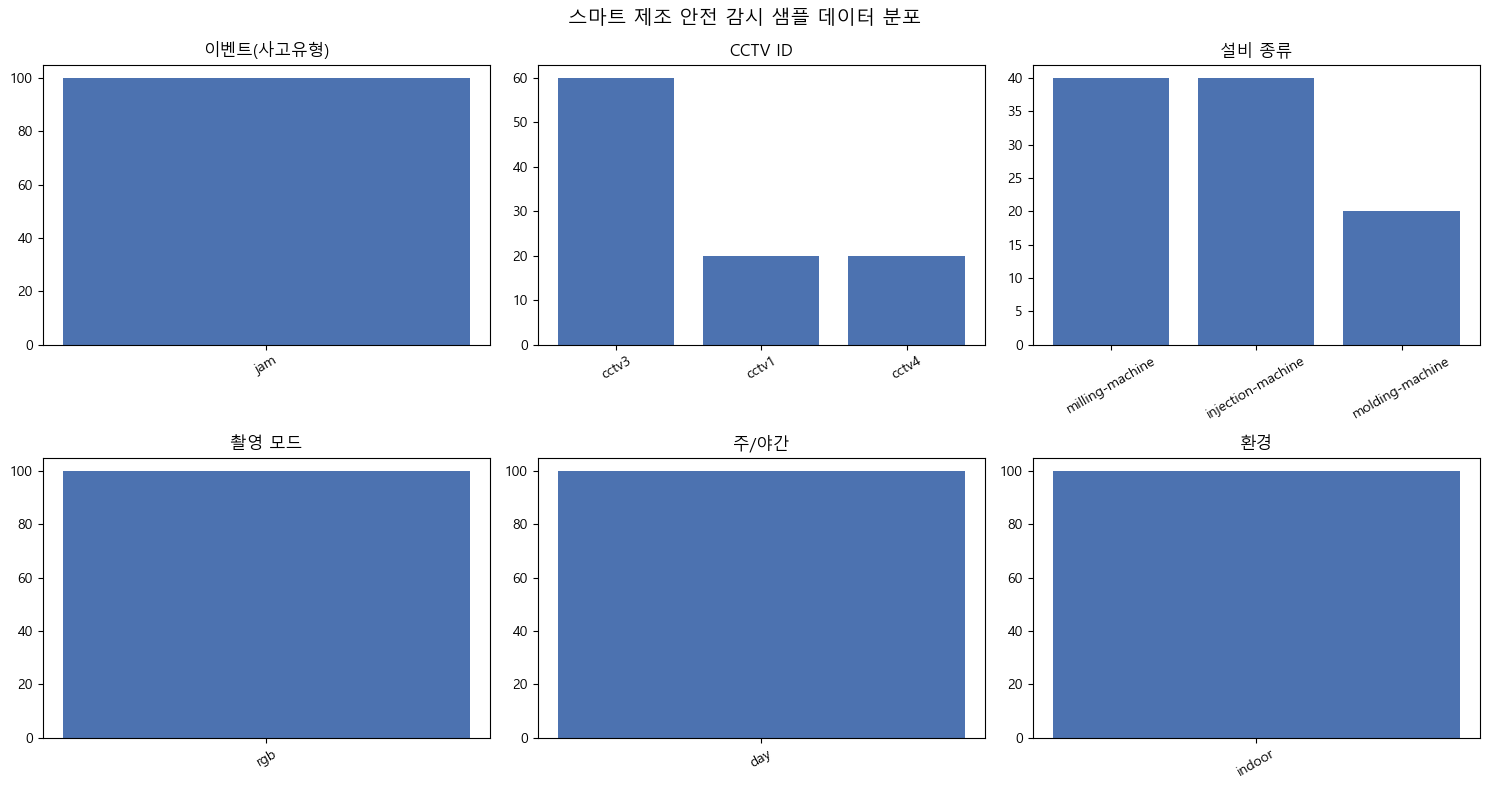

저장: c:\MyCursorLab\06_Object_Detection\smart_factory\eda\distribution_overview.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("스마트 제조 안전 감시 샘플 데이터 분포", fontsize=14)

plot_cols = [
    ("event", "이벤트(사고유형)"),
    ("camera_id", "CCTV ID"),
    ("facility_name", "설비 종류"),
    ("mode", "촬영 모드"),
    ("shoot_time", "주/야간"),
    ("environment", "환경"),
]

for ax, (col, title) in zip(axes.flat, plot_cols):
    counts = df_img[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color="#4C72B0")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
out_path = EDA_OUT / "distribution_overview.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"저장: {out_path}")

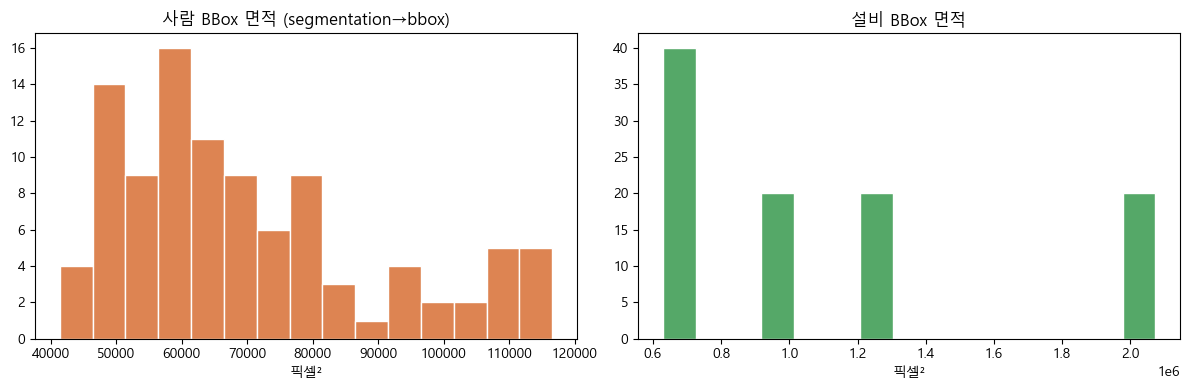

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_img["human_bbox_area"].dropna(), bins=15, color="#DD8452", edgecolor="white")
axes[0].set_title("사람 BBox 면적 (segmentation→bbox)")
axes[0].set_xlabel("픽셀²")

axes[1].hist(df_img["facility_bbox_area"].dropna(), bins=15, color="#55A868", edgecolor="white")
axes[1].set_title("설비 BBox 면적")
axes[1].set_xlabel("픽셀²")

plt.tight_layout()
out_path = EDA_OUT / "bbox_area_distribution.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()

## 4. 샘플 이미지 + 라벨 시각화

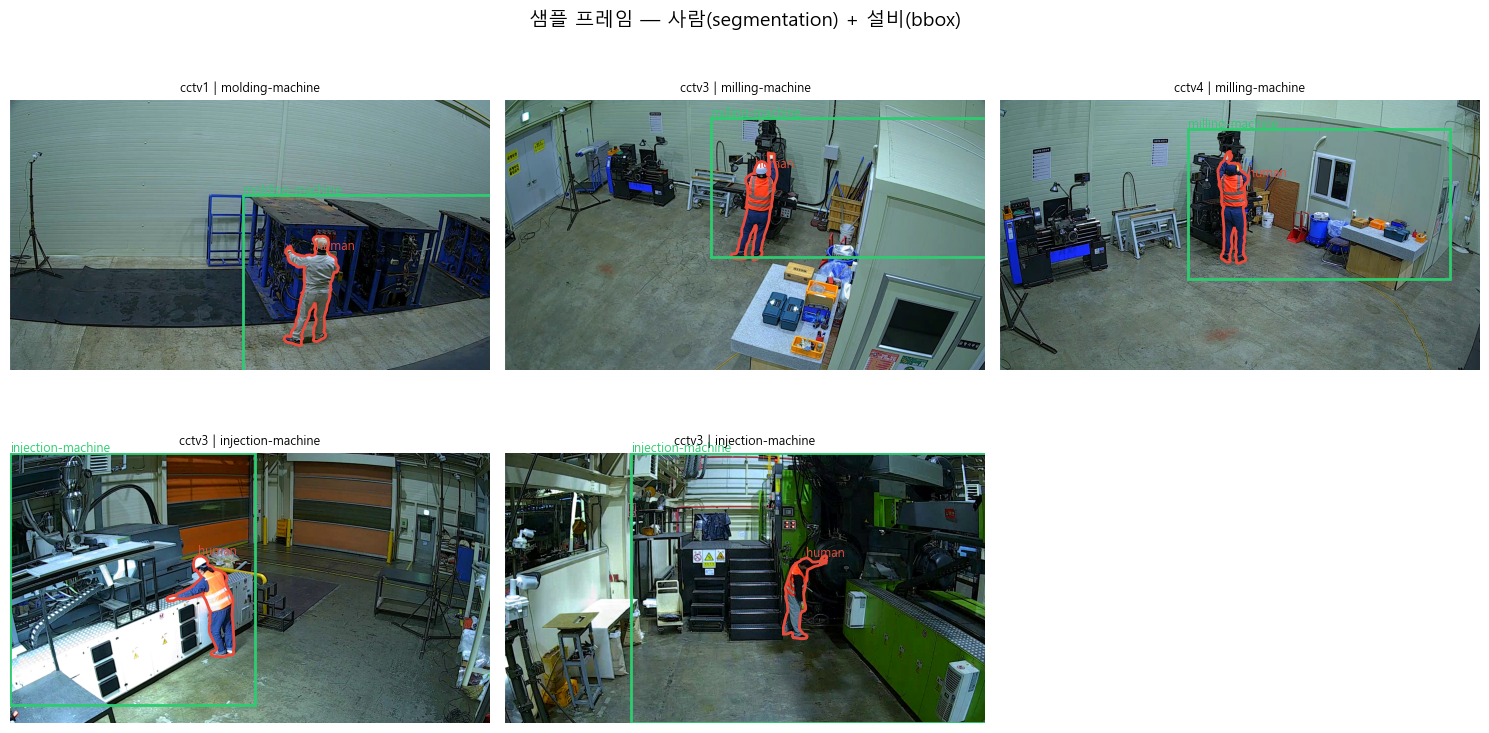

In [6]:
COLORS = {"human": "#E74C3C", "facility": "#2ECC71"}

def draw_annotations(ax, data: dict):
    for ann in data.get("annotations", []):
        if ann["id"].startswith("h") and ann.get("segmentation"):
            seg = np.array(ann["segmentation"]).reshape(-1, 2)
            ax.add_patch(plt.Polygon(seg, fill=False, edgecolor=COLORS["human"], linewidth=2))
            ax.text(seg[0, 0], seg[0, 1] - 5, "human", color=COLORS["human"], fontsize=9)
        if ann["id"].startswith("m") and ann.get("bbox"):
            x, y, w, h = ann["bbox"]
            rect = patches.Rectangle((x, y), w, h, fill=False, edgecolor=COLORS["facility"], linewidth=2)
            ax.add_patch(rect)
            facility = data.get("object_information_facility", {}).get("facility_name", "facility")
            ax.text(x, y - 5, facility, color=COLORS["facility"], fontsize=9)

sample_jsons = sorted(label_root.rglob("*_01.json"))  # 영상당 1장 (샘플 5개)
n_samples = len(sample_jsons)
ncols = min(3, n_samples)
nrows = (n_samples + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
fig.suptitle("샘플 프레임 — 사람(segmentation) + 설비(bbox)", fontsize=14)

axes_flat = np.atleast_1d(axes).ravel()
for ax in axes_flat[n_samples:]:
    ax.set_visible(False)

for ax, jp in zip(axes_flat[:n_samples], sample_jsons):
    data = load_json(jp)
    img_name = data["meta_information"]["file_name"]
    rel = jp.parent.relative_to(label_root)
    img_path = raw_root / rel / img_name
    img = Image.open(img_path)
    ax.imshow(img)
    draw_annotations(ax, data)
    meta = data["meta_information"]
    facility = data.get("object_information_facility", {}).get("facility_name", "")
    ax.set_title(f"{meta['camera_id']} | {facility}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
out_path = EDA_OUT / "sample_annotations.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()

## 5. 영상 시퀀스 분석

,video,frames,camera_id,facility
0,human-accident_jam_rgb_0957_cctv1.mp4,20,cctv1,molding-machine
1,human-accident_jam_rgb_1048_cctv3.mp4,20,cctv3,milling-machine
2,human-accident_jam_rgb_1069_cctv4.mp4,20,cctv4,milling-machine
3,human-accident_jam_rgb_1892_cctv3.mp4,20,cctv3,injection-machine
4,human-accident_jam_rgb_2031_cctv3.mp4,20,cctv3,injection-machine


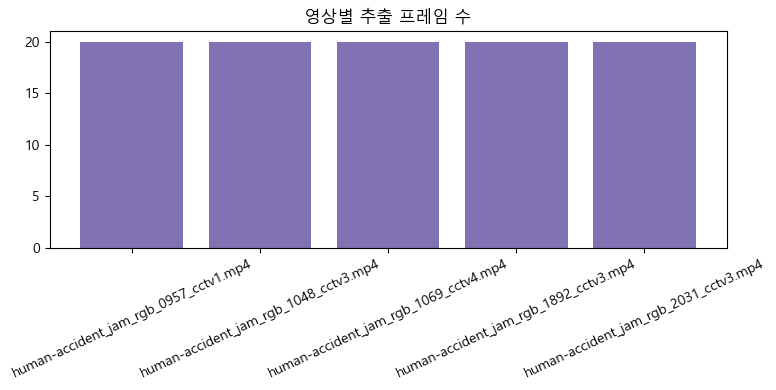

In [7]:
video_stats = []
for mp4 in sorted(raw_root.rglob("*.mp4")):
    folder = mp4.parent
    frames = sorted(folder.glob("*.png"))
    meta_json = label_root / folder.relative_to(raw_root) / f"{folder.name}.json"
    meta = load_json(meta_json)["meta_information"] if meta_json.exists() else {}
    video_stats.append({
        "video": mp4.name,
        "frames": len(frames),
        "camera_id": meta.get("camera_id"),
        "facility": load_json(meta_json).get("object_information_facility", {}).get("facility_name") if meta_json.exists() else None,
    })

df_video = pd.DataFrame(video_stats)
display(df_video)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df_video["video"], df_video["frames"], color="#8172B3")
ax.set_title("영상별 추출 프레임 수")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 6. EDA 요약

| 항목 | 관찰 결과 |
|------|----------|
| 사고 유형 | 샘플은 **jam(끼임)** 만 포함 |
| 해상도 | FHD 1920×1080 (RGB) |
| 객체 | 사람(segmentation), 설비(bbox) 동시 라벨링 |
| 설비 | molding / milling / injection 3종 |
| CCTV | cctv1, cctv3, cctv4 분포 |

<br>

> 다음 단계: `smart_factory/prepare_yolo.py`로 YOLO 형식 변환 후 `13_YOLO26_SmartFactory_Monitor.ipynb`에서 YOLO26 학습·영상 추론

In [8]:
summary = {
    "total_images": len(df_img),
    "total_videos": len(df_vid),
    "events": df_img["event"].value_counts().to_dict(),
    "facilities": df_img["facility_name"].value_counts().to_dict(),
    "cameras": df_img["camera_id"].value_counts().to_dict(),
}
summary_path = EDA_OUT / "eda_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(summary, indent=2, ensure_ascii=False))
print(f"\n요약 저장: {summary_path}")

{
  "total_images": 100,
  "total_videos": 5,
  "events": {
    "jam": 100
  },
  "facilities": {
    "milling-machine": 40,
    "injection-machine": 40,
    "molding-machine": 20
  },
  "cameras": {
    "cctv3": 60,
    "cctv1": 20,
    "cctv4": 20
  }
}

요약 저장: c:\MyCursorLab\06_Object_Detection\smart_factory\eda\eda_summary.json
